### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

In [3]:
from imblearn.over_sampling import RandomOverSampler
from feature_engine.selection import SmartCorrelatedSelection

### Step 2: Load Data

In [4]:
df = pd.read_csv('./data/vehicles.csv')

In [13]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

In [5]:
df.shape

(48120, 2)

In [6]:
df.head()

,DateTime,Vehicles
0,2015-11-01 00:00:00,15
1,2015-11-01 01:00:00,13
2,2015-11-01 02:00:00,10
3,2015-11-01 03:00:00,7
4,2015-11-01 04:00:00,9


### Step 3: Exploaring Data

#### Basic Info

In [14]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
DateTime,48120,2016-09-19 06:03:56.109725696,2015-11-01 00:00:00,2016-04-16 01:45:00,2016-09-30 03:30:00,2017-02-25 16:00:00,2017-06-30 23:00:00,NaN
Vehicles,48120.0,22.791334,1.0,9.0,15.0,29.0,180.0,20.750063


In [15]:
feature_info = pd.DataFrame(
    {'null': df.isnull().sum(), 'null(%)': df.isnull().sum()/len(df), 'unique': df.nunique(), 'type': df.dtypes}
)

In [16]:
feature_info

,null,null(%),unique,type
DateTime,0,0.0,14592,datetime64[ns]
Vehicles,0,0.0,141,int64


#### Target Distribution

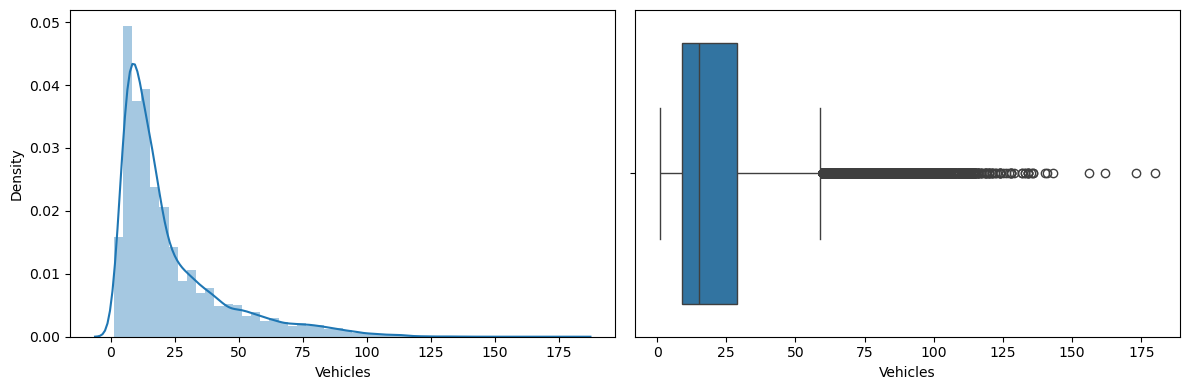

In [12]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.distplot(df['Vehicles'])
plt.subplot(1, 2, 2)
sns.boxplot(df['Vehicles'], orient='h')
plt.tight_layout()

### Step 4: Featuer Engineering

#### Building Feature

In [18]:
df['year'] = df['DateTime'].map(lambda x: x.year)
df['month'] = df['DateTime'].map(lambda x: x.month)
df['day'] = df['DateTime'].map(lambda x: x.day)
df['hour'] = df['DateTime'].map(lambda x: x.hour)
df['weekday'] = df['DateTime'].map(lambda x: x.weekday())
df['dayofyear'] = df['DateTime'].map(lambda x: x.dayofyear)
df['weekofyear'] = df['DateTime'].map(lambda x: x.weekofyear)

#### Heat Map

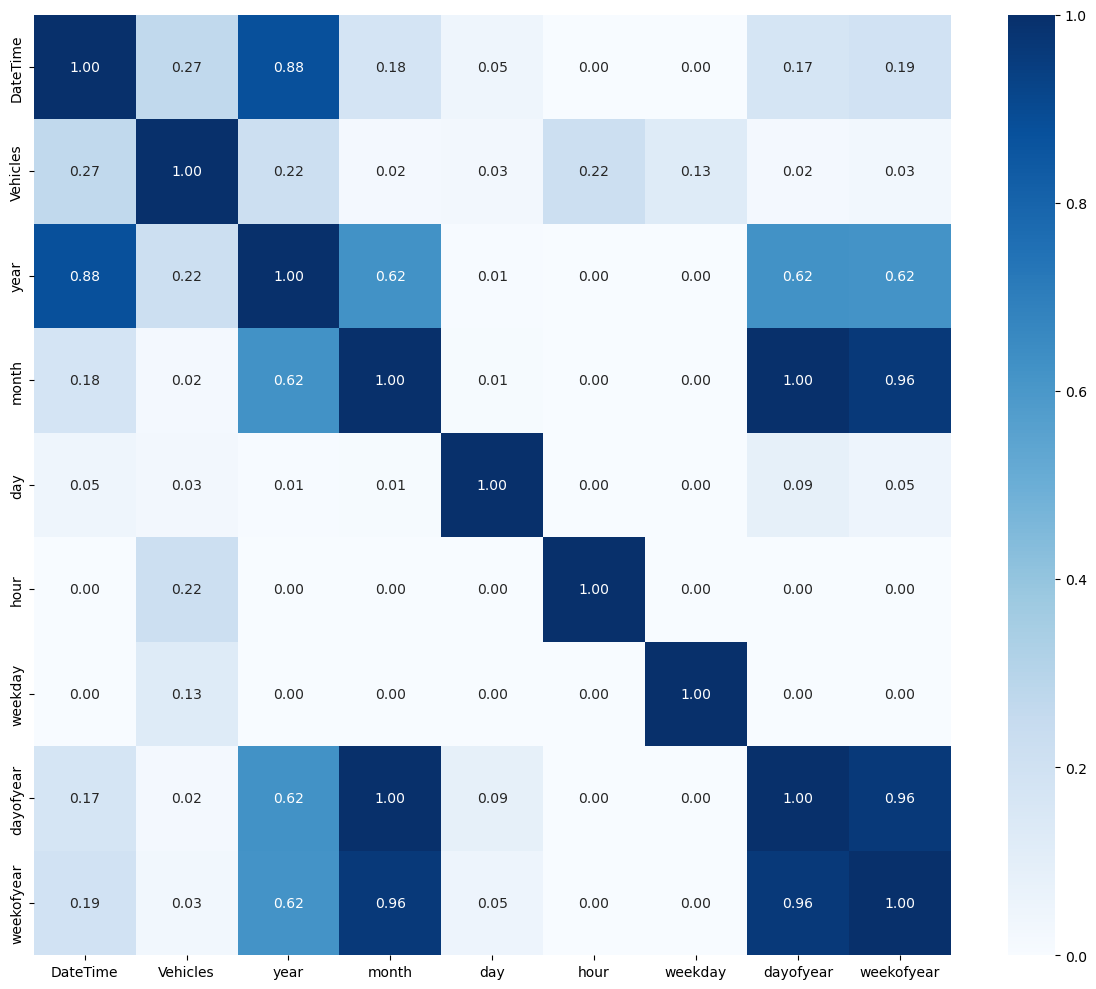

In [21]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df.corr().abs(),
    fmt='.2f',
    annot=True,
    cmap=plt.cm.Blues
)
plt.tight_layout()

### Step 5: Preparing Data

#### Select Features

In [114]:
features = df.drop(['DateTime', 'Vehicles'], axis=1)
target = df['Vehicles']

In [115]:
raw_features = features.columns.to_list()

In [116]:
selector = SmartCorrelatedSelection(threshold=0.8, selection_method='corr_with_target')

In [117]:
features = selector.fit_transform(features, target)

In [118]:
deal_features = features.columns.to_list()

In [119]:
print('raw features :', raw_features)
print('deal features :', deal_features)
print('delete features :', set(raw_features)-set(deal_features))

raw features : ['year', 'month', 'day', 'hour', 'weekday', 'dayofyear', 'weekofyear']
deal features : ['year', 'day', 'hour', 'weekday', 'weekofyear']
delete features : {'dayofyear', 'month'}


#### Split Data

In [120]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target, 
    test_size=0.2,
    random_state=42
)

#### Normalization

In [121]:
scaler = StandardScaler()

In [122]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Step 6: Model Development

#### Building Model

In [123]:
rfr = RandomForestRegressor()

#### Training Model

In [124]:
scores = cross_val_score(
    rfr,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    error_score='raise'
)

In [125]:
print('Accuracy Scores:', [round(x, 3) for x in scores])
print('Accuracy Score:', round(scores.mean(), 2))

Accuracy Scores: [-0.41, -0.389, -0.395, -0.418, -0.406]
Accuracy Score: -0.4


In [126]:
rfr.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### Evaluate Model

In [127]:
y_pred = rfr.predict(X_test)

In [128]:
print('Testing Accuracy Score :', round(metrics.mean_absolute_error(y_test, y_pred), 2))

Testing Accuracy Score : 19.18


#### Prediction Model

In [130]:
deal_features

['year', 'day', 'hour', 'weekday', 'weekofyear']

In [134]:
sample = pd.DataFrame(
    [[2015, 11, 0, 6, 2]],
    columns=deal_features
)

In [137]:
sample = scaler.transform(sample)

In [138]:
res = rfr.predict(sample)

In [139]:
res

array([8.36618831])